---

# Part 1: Legacy Loan-Level PD Model

## Dataset

In [1]:
#The dataset csv file is about 1.6GB in size.  
#First obtain the shape and column names of the dataset.

import pandas as pd
import numpy as np

# Count columns only (reads just header)
n_cols = len(pd.read_csv("../accepted_2007_to_2018Q4.csv", nrows=0).columns)

# Count rows efficiently in streaming fashion
n_rows = sum(1 for _ in open("../accepted_2007_to_2018Q4.csv", encoding="utf-8")) - 1

# Read only header
df_header = pd.read_csv("../accepted_2007_to_2018Q4.csv", nrows=0)


print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
# Column names
print(df_header.columns.tolist())



Rows: 2,260,701
Columns: 151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_sta

### Subsetting

1. Keep only selected columns 

- 27 of 151 (25 predictors + loan_status target + issue_d for time grouping), per feature selection rationale. 

In [2]:
# Keeping only selected columns for PD modeling

selected_cols = [
    # Target + time
    'loan_status', 'issue_d', 'last_pymnt_d',   # last_pymnt_d: carried for Macro linkage step, exit/default timing (NOT a model feature)
    # Loan terms
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose',
    # Borrower financials
    'annual_inc', 'dti', 'emp_length', 'home_ownership', 'verification_status',
    # Credit history
    'fico_range_low', 'fico_range_high', 'earliest_cr_line', 'delinq_2yrs',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'pub_rec_bankruptcies', 'mort_acc', 'acc_open_past_24mths'
]

df = pd.read_csv('../accepted_2007_to_2018Q4.csv', usecols=selected_cols, low_memory=False)

print(f"Shape after loading selected columns: {df.shape}")
print(f"\nloan_status distribution:")
print(df['loan_status'].value_counts(dropna=False))

Shape after loading selected columns: (2260701, 28)

loan_status distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64


2. Generate the binary outcome 

- Define the default flag: default = 1 for Charged Off / Default, default = 0 for Fully Paid. 

- Restrict to loans with a terminal (resolved) status. Loans still Current, Late, or In Grace Period are dropped because their final outcome is unknown. 
This step reduces the data from 2.26M to ~1.35M loans, with an observed default rate of ~20%.

In [3]:
# Map loan_status to a binary default flag, keeping only terminal (resolved) outcomes
default_statuses = ['Charged Off', 'Default',
                    'Does not meet the credit policy. Status:Charged Off']
paid_statuses    = ['Fully Paid',
                    'Does not meet the credit policy. Status:Fully Paid']

# Keep only loans with a known terminal outcome
terminal = df[df['loan_status'].isin(default_statuses + paid_statuses)].copy()

# Create binary target: 1 = default/charged off, 0 = fully paid
terminal['default'] = terminal['loan_status'].isin(default_statuses).astype(int)

print(f"Shape after filtering to terminal loans: {terminal.shape}")
print(f"\nDefault flag distribution:")
print(terminal['default'].value_counts())
print(f"\nDefault rate: {terminal['default'].mean():.4f}")

Shape after filtering to terminal loans: (1348099, 29)

Default flag distribution:
default
0    1078739
1     269360
Name: count, dtype: int64

Default rate: 0.1998


3. Stratified sampling for the PD model 

For efficient iterative training of the PD model, a stratified random sample (~200,000 loans) is drawn from the 1.35M terminal loans while preserving the ~20% default class balance.

The full 1.35M terminal-loan dataset is retained separately for the subsequent macro-linkage model, where quarterly default-rate aggregates benefit from the larger population.

In [4]:
# Stratified sample to ~200k rows for efficient PD model training (Layer 1).
# The full `terminal` dataset is preserved for Layer 2's quarterly aggregation.

sample_frac = 200_000 / len(terminal)

# Stratified sample by the default flag to preserve class balance (~20% default rate)
sample = (
    terminal
    .groupby('default', group_keys=False)
    .sample(frac=sample_frac, random_state=42)
    .reset_index(drop=True)
)

print(f"Sampled shape: {sample.shape}")
print(f"Default rate in sample: {sample['default'].mean():.4f}")

Sampled shape: (200000, 29)
Default rate in sample: 0.1998


### Data Cleaning

Inspect datatype and missing values:

In [5]:
print(f"{'Column':<25} {'Dtype':<15} {'Nulls':<10} {'Unique':<10} Sample values")
print("=" * 110)

for col in sample.columns:
    dtype = str(sample[col].dtype)
    nulls = sample[col].isnull().sum()
    nunique = sample[col].nunique()
    
    # Show up to 5 sample values (drop nulls for clarity)
    sample_vals = sample[col].dropna().unique()[:5]
    sample_str = str(list(sample_vals))
    if len(sample_str) > 50:
        sample_str = sample_str[:47] + "..."
    
    print(f"{col:<25} {dtype:<15} {nulls:<10} {nunique:<10} {sample_str}")

Column                    Dtype           Nulls      Unique     Sample values
loan_amnt                 float64         0          1438       [np.float64(10000.0), np.float64(24000.0), np.f...
term                      str             0          2          [' 36 months', ' 60 months']
int_rate                  float64         0          628        [np.float64(11.47), np.float64(14.65), np.float...
installment               float64         0          41851      [np.float64(329.62), np.float64(566.56), np.flo...
grade                     str             0          7          ['B', 'C', 'A', 'D', 'E']
sub_grade                 str             0          35         ['B5', 'C5', 'B3', 'B1', 'C3']
emp_length                str             11679      11         ['10+ years', '1 year', '2 years', '4 years', '...
home_ownership            str             0          6          ['MORTGAGE', 'RENT', 'OWN', 'OTHER', 'ANY']
annual_inc                float64         0          15677      [np.float64(

##### 1. Cleaning four columns currently stored in string format:


In [6]:
# 1. term: ' 36 months' / ' 60 months' → 36 / 60 (int)
sample['term'] = sample['term'].str.extract(r'(\d+)').astype(int)

# 2. emp_length: '< 1 year' → 0, '10+ years' → 10, 'N years' → N
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
sample['emp_length'] = sample['emp_length'].map(emp_map)

# 3. issue_d: 'May-2016' → datetime
sample['issue_d'] = pd.to_datetime(sample['issue_d'], format='%b-%Y')

# 4. earliest_cr_line: 'Apr-2006' → datetime, then engineer into credit-history length (years)
sample['earliest_cr_line'] = pd.to_datetime(sample['earliest_cr_line'], format='%b-%Y')
sample['credit_history_yrs'] = (
    (sample['issue_d'] - sample['earliest_cr_line']).dt.days / 365.25
)

# Drop the raw earliest_cr_line now that we've engineered the feature
sample = sample.drop(columns=['earliest_cr_line'])

# Quick verification
print("After cleaning:\n")
print(sample[['term', 'emp_length', 'issue_d', 'credit_history_yrs']].head())
print(f"\nMissing values per cleaned column:")
print(sample[['term', 'emp_length', 'issue_d', 'credit_history_yrs']].isnull().sum())

After cleaning:

   term  emp_length    issue_d  credit_history_yrs
0    36        10.0 2016-05-01           10.083504
1    60         1.0 2015-10-01            9.500342
2    36         2.0 2014-03-01           13.075975
3    36        10.0 2015-01-01           19.085558
4    36        10.0 2016-01-01           26.997947

Missing values per cleaned column:
term                      0
emp_length            11679
issue_d                   0
credit_history_yrs        5
dtype: int64


#### 2. Missing Values

Columns with Missing Values

- `emp_length`: 11,679 nulls (~5.8%) — borrowers who did not disclose employment length
- `acc_open_past_24mths`: 7,449 nulls (~3.7%)
- `mort_acc`: 7,449 nulls (~3.7%) — same null count as above, suggesting overlap among borrowers
- `pub_rec_bankruptcies`: 223 nulls (~0.1%)
- `revol_util`: 134 nulls (minimal)
- `dti`: 61 nulls (minimal)
- `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `total_acc`, and `earliest_cr_line` / `credit_history_yrs`: 5 nulls each — likely the same borrowers missing credit-bureau information entirely

Handling Missing Values

- `emp_length`: impute with the median and add a missingness indicator variable.

  Missing employment information may itself contain predictive signal, so the missingness is preserved through an additional binary flag alongside imputation.

- `acc_open_past_24mths`, `mort_acc`: impute with 0.

  These are count variables, where missing values likely indicate no accounts reported by the credit bureau.

- Other features with missing values: drop missing observations.

  The remaining missing counts are extremely small and have negligible impact on sample size.

In [7]:
# 1. emp_length — median imputation + missingness flag.
sample['emp_length_missing'] = sample['emp_length'].isnull().astype(int)
emp_length_median = sample['emp_length'].median()   # captured for consistent imputation when scoring the full set (for macro linkage model)
sample['emp_length'] = sample['emp_length'].fillna(emp_length_median)

# 2. acc_open_past_24mths, mort_acc — impute 0.
sample['acc_open_past_24mths'] = sample['acc_open_past_24mths'].fillna(0)
sample['mort_acc'] = sample['mort_acc'].fillna(0)

# 3. Tiny nulls (~5 rows) — Drop.
small_null_cols = ['dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
                   'pub_rec', 'total_acc', 'credit_history_yrs',
                   'revol_util', 'pub_rec_bankruptcies']
sample = sample.dropna(subset=small_null_cols)


# Verify
print(f"Shape after missing-value handling: {sample.shape}")
print(f"\nRemaining nulls:")
print(sample.isnull().sum()[sample.isnull().sum() > 0])
print(f"\nemp_length_missing distribution:")
print(sample['emp_length_missing'].value_counts())

Shape after missing-value handling: (199587, 30)

Remaining nulls:
last_pymnt_d    352
dtype: int64

emp_length_missing distribution:
emp_length_missing
0    187975
1     11612
Name: count, dtype: int64


#### 3. Collapse FICO Range

In [8]:
# Collapse perfectly correlated FICO range columns into a single midpoint feature
sample['fico'] = (sample['fico_range_low'] + sample['fico_range_high']) / 2
sample = sample.drop(columns=['fico_range_low', 'fico_range_high'])

## Model Preparation

Build three feature sets:  

• Primary/base model: excludes LendingClub proprietary risk grades

• Sensitivity 1: same as base model, but excludes interest rate

• Sensitivity 2: excludes interest rate and adds LendingClub sub-grade indicators


1. Build Feature Matrix for Both Base and Sensitivity Models

- Define feature groups (numeric, categorical, LC risk grades)
- One-hot encode categoricals
- Construct three matrices: base, sensitivity 1, and sensitivity 2
- Define outcome

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Columns that are NOT features (target, time grouping, raw outcome string)
non_feature_cols = ['loan_status', 'issue_d', 'default', 'grade', 'last_pymnt_d']   # last_pymnt_d carried for Layer 2, excluded from features

# All categorical columns to one-hot encode
categorical_cols = ['purpose', 'home_ownership', 'verification_status']

# Lending Club's proprietary risk assessment — kept separate for the sensitivity comparison
lc_risk_cols = ['sub_grade']

# Features excluded from sensitivity model only
sensitivity_drop_cols = ['int_rate']

# All other features are numeric
numeric_cols = [c for c in sample.columns
                if c not in non_feature_cols + categorical_cols + lc_risk_cols]


# --- Build feature matrix ---
# Primary: full feature set including int_rate
X_base = pd.get_dummies(sample[numeric_cols + categorical_cols],
                        columns=categorical_cols, drop_first=True)

# Sen 1: drop int_rate only
X_sen1 = X_base.drop(columns=sensitivity_drop_cols)

# Sen 2: drop int_rate, add sub_grade
X_sen2 = pd.concat([
    X_base.drop(columns=sensitivity_drop_cols),
    pd.get_dummies(sample[lc_risk_cols], columns=lc_risk_cols, drop_first=True)
], axis=1)


# Convert any boolean dummy columns to int (sklearn prefers numeric)
for X in [X_base, X_sen1, X_sen2]:
    bool_cols = X.select_dtypes('bool').columns
    X[bool_cols] = X[bool_cols].astype(int)

y = sample['default']

print(f"Primary model features:       {X_base.shape}")
print(f"Sen 1 features (drop int_rate):            {X_sen1.shape}")
print(f"Sen 2 features (drop int_rate, add sub_grade): {X_sen2.shape}")

Primary model features:       (199587, 40)
Sen 1 features (drop int_rate):            (199587, 39)
Sen 2 features (drop int_rate, add sub_grade): (199587, 73)


2. Train/Test Split

In [10]:

# --- Train/test split ---
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y)

X_sen1_train, X_sen1_test, _, _ = train_test_split(
    X_sen1, y, test_size=0.2, random_state=42, stratify=y)
    # Same random seed and stratification produce identical train/test row assignments, so y_train and y_test need not be recreated
    
X_sen2_train, X_sen2_test, _, _ = train_test_split(
    X_sen2, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_base_train.shape[0]:,} | Test size: {X_base_test.shape[0]:,}")
print(f"Default rate - Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")




Train size: 159,669 | Test size: 39,918
Default rate - Train: 0.200 | Test: 0.200


3. Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# --- Scale numeric features only (exclude binary/dummy columns) ---
def scale_with_passthrough(X_train, X_test):
    binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
    numeric_to_scale = [c for c in X_train.columns if c not in binary_cols]
    
    scaler = StandardScaler()
    
    X_train_sc = X_train.copy()
    X_test_sc  = X_test.copy()
    
    X_train_sc[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
    X_test_sc[numeric_to_scale]  = scaler.transform(X_test[numeric_to_scale])
    
    return X_train_sc, X_test_sc, scaler

X_base_train_sc, X_base_test_sc, scaler_base = scale_with_passthrough(X_base_train, X_base_test)
X_sen1_train_sc, X_sen1_test_sc, scaler_sen1 = scale_with_passthrough(X_sen1_train, X_sen1_test)
X_sen2_train_sc, X_sen2_test_sc, scaler_sen2 = scale_with_passthrough(X_sen2_train, X_sen2_test)


binary_cols = [c for c in X_base_train.columns if X_base_train[c].nunique() == 2]
scaled_cols = [c for c in X_base_train.columns if c not in binary_cols]

print(f"Binary cols not scaled ({len(binary_cols)}): {binary_cols}")
print(f"Numeric cols scaled    ({len(scaled_cols)}): {scaled_cols}")

Binary cols not scaled (22): ['term', 'emp_length_missing', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified']
Numeric cols scaled    (18): ['loan_amnt', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'acc_open_past_24mths', 'mort_acc', 'pub_rec_bankruptcies', 'credit_history_yrs', 'fico']


## Model Training

In [12]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Fit Primary and Sensitivity Models

In [13]:
from sklearn.linear_model import LogisticRegression

lr_params = dict(
    penalty='l2',        # L2 regularization: shrinks coefficients to reduce overfitting (standard credit-scorecard choice)
    C=1.0,               # Regularization strength (1/lambda); 1.0 is moderate; inverse regularization strength: higher = less regularization
    max_iter=1000,       # increased from default 100 to ensure convergence on this feature set
    solver='liblinear',  # efficient and stable for large binary classification datasets
    #class_weight='balanced',  # corrects for default/non-default class imbalance in LC data
    random_state=42      # reproducibility
)
# class_weight='balanced',   # Removed: distorts probability calibration; see writeup.


model_base = LogisticRegression(**lr_params)
model_base.fit(X_base_train_sc, y_train)
print(f"Primary model:    fit on {X_base_train_sc.shape[0]:,} loans × {X_base_train_sc.shape[1]} features")

model_sen1 = LogisticRegression(**lr_params)
model_sen1.fit(X_sen1_train_sc, y_train)
print(f"Sen 1 model:      fit on {X_sen1_train_sc.shape[0]:,} loans × {X_sen1_train_sc.shape[1]} features")

model_sen2 = LogisticRegression(**lr_params)
model_sen2.fit(X_sen2_train_sc, y_train)
print(f"Sen 2 model:      fit on {X_sen2_train_sc.shape[0]:,} loans × {X_sen2_train_sc.shape[1]} features")

Primary model:    fit on 159,669 loans × 40 features
Sen 1 model:      fit on 159,669 loans × 39 features
Sen 2 model:      fit on 159,669 loans × 73 features


## Model Evaluation

### 1.Model Discrimination: ROC-AUC

Primary model AUC (int_rate, no LC grade):          0.7081
Sen 1 AUC (drop int_rate, no LC grade):             0.7035  (-0.0047 vs primary)
Sen 2 AUC (drop int_rate, add sub_grade):           0.7101  (+0.0019 vs primary)


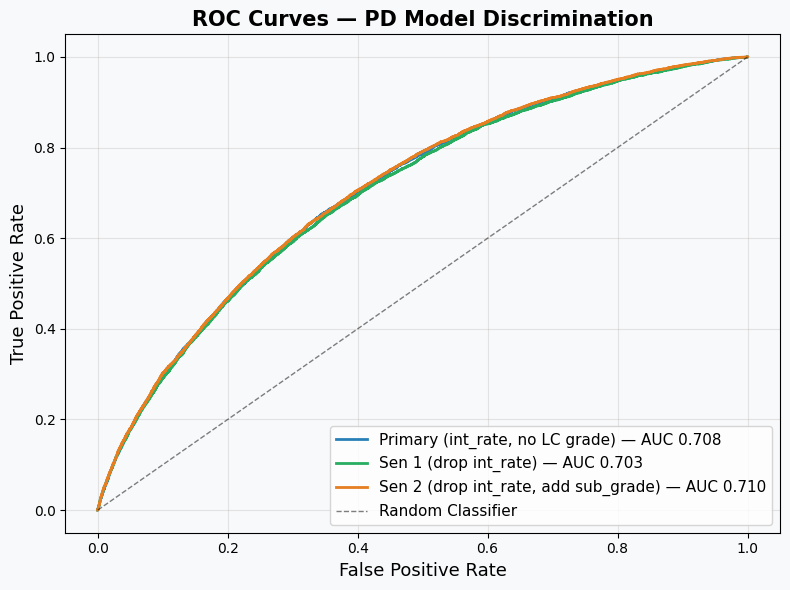

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict default probabilities on the test set
pd_base = model_base.predict_proba(X_base_test_sc)[:, 1]
pd_sen1 = model_sen1.predict_proba(X_sen1_test_sc)[:, 1]
pd_sen2 = model_sen2.predict_proba(X_sen2_test_sc)[:, 1]

# Compute AUCs
auc_base = roc_auc_score(y_test, pd_base)
auc_sen1 = roc_auc_score(y_test, pd_sen1)
auc_sen2 = roc_auc_score(y_test, pd_sen2)

print(f"Primary model AUC (int_rate, no LC grade):          {auc_base:.4f}")
print(f"Sen 1 AUC (drop int_rate, no LC grade):             {auc_sen1:.4f}  ({auc_sen1 - auc_base:+.4f} vs primary)")
print(f"Sen 2 AUC (drop int_rate, add sub_grade):           {auc_sen2:.4f}  ({auc_sen2 - auc_base:+.4f} vs primary)")

# Plot ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, pd_base)
fpr_sen1, tpr_sen1, _ = roc_curve(y_test, pd_sen1)
fpr_sen2, tpr_sen2, _ = roc_curve(y_test, pd_sen2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

ax.plot(fpr_base, tpr_base, color='#2980b9', lw=2,
        label=f'Primary (int_rate, no LC grade) — AUC {auc_base:.3f}')
ax.plot(fpr_sen1, tpr_sen1, color='#27ae60', lw=2,
        label=f'Sen 1 (drop int_rate) — AUC {auc_sen1:.3f}')
ax.plot(fpr_sen2, tpr_sen2, color='#e67e22', lw=2,
        label=f'Sen 2 (drop int_rate, add sub_grade) — AUC {auc_sen2:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — PD Model Discrimination', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Discrimination: Kolmogorov–Smirnov (KS) Statistic

In [15]:
from scipy.stats import ks_2samp

# --- KS Statistic ---
# KS measures the maximum separation between the cumulative distribution
# of predicted PDs for defaults vs non-defaults

ks_base = ks_2samp(pd_base[y_test == 1], pd_base[y_test == 0])
ks_sen1 = ks_2samp(pd_sen1[y_test == 1], pd_sen1[y_test == 0])
ks_sen2 = ks_2samp(pd_sen2[y_test == 1], pd_sen2[y_test == 0])

print(f"Primary model KS:  {ks_base.statistic:.4f}")
print(f"Sen 1 KS:          {ks_sen1.statistic:.4f}  ({ks_sen1.statistic - ks_base.statistic:+.4f} vs primary)")
print(f"Sen 2 KS:          {ks_sen2.statistic:.4f}  ({ks_sen2.statistic - ks_base.statistic:+.4f} vs primary)")

Primary model KS:  0.3085
Sen 1 KS:          0.2990  (-0.0095 vs primary)
Sen 2 KS:          0.3071  (-0.0014 vs primary)


### 3. Probability Calibration

Calibration Table (Primary Model):
        n_loans  avg_pd_pred  actual_default_rate
decile                                           
0          3992       0.0522               0.0521
1          3992       0.0842               0.0754
2          3992       0.1089               0.0977
3          3991       0.1325               0.1313
4          3992       0.1573               0.1668
5          3992       0.1841               0.1844
6          3991       0.2165               0.2390
7          3992       0.2596               0.2743
8          3992       0.3268               0.3231
9          3992       0.4812               0.4532

Calibration Table (Sen 1 (drop int_rate)):
        n_loans  avg_pd_pred  actual_default_rate
decile                                           
0          3992       0.0544               0.0551
1          3992       0.0887               0.0789
2          3992       0.1131               0.1025
3          3991       0.1353               0.1341
4          3992      

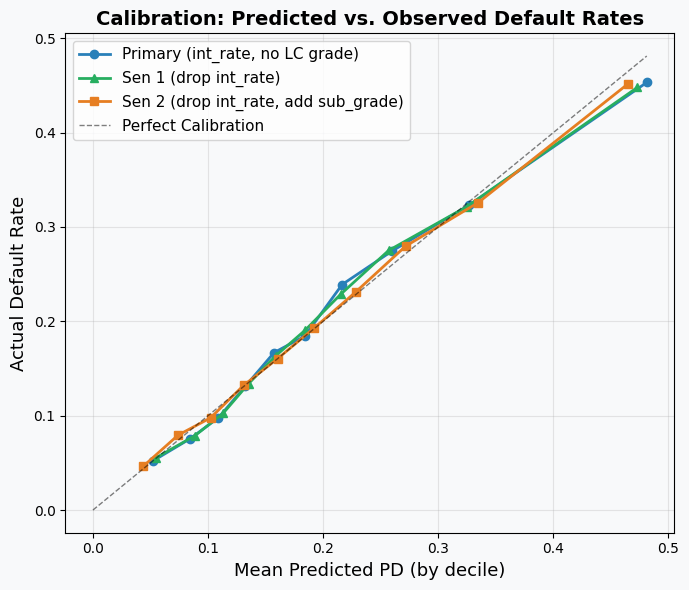

In [16]:
# Build calibration tables for all three models
def calibration_table(pd_pred, y_actual, label):
    df = pd.DataFrame({'pd_pred': pd_pred, 'actual': y_actual.values})
    df['decile'] = pd.qcut(df['pd_pred'], q=10, labels=False, duplicates='drop')
    summary = df.groupby('decile').agg(
        n_loans=('actual', 'size'),
        avg_pd_pred=('pd_pred', 'mean'),
        actual_default_rate=('actual', 'mean')
    ).round(4)
    print(f"Calibration Table ({label}):\n{summary}\n")
    return summary

calib_base = calibration_table(pd_base, y_test, "Primary Model")
calib_sen1 = calibration_table(pd_sen1, y_test, "Sen 1 (drop int_rate)")
calib_sen2 = calibration_table(pd_sen2, y_test, "Sen 2 (drop int_rate, add sub_grade)")

# Calibration plot — all three models
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

ax.plot(calib_base['avg_pd_pred'], calib_base['actual_default_rate'],
        marker='o', lw=2, color='#2980b9', label='Primary (int_rate, no LC grade)')
ax.plot(calib_sen1['avg_pd_pred'], calib_sen1['actual_default_rate'],
        marker='^', lw=2, color='#27ae60', label='Sen 1 (drop int_rate)')
ax.plot(calib_sen2['avg_pd_pred'], calib_sen2['actual_default_rate'],
        marker='s', lw=2, color='#e67e22', label='Sen 2 (drop int_rate, add sub_grade)')

max_val = max(calib_base['avg_pd_pred'].max(), calib_sen1['avg_pd_pred'].max(), calib_sen2['avg_pd_pred'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5, label='Perfect Calibration')

ax.set_xlabel('Mean Predicted PD (by decile)', fontsize=13)
ax.set_ylabel('Actual Default Rate', fontsize=13)
ax.set_title('Calibration: Predicted vs. Observed Default Rates', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Default Drivers: Coefficient Interpretation & Odds Ratios


In [17]:
import numpy as np

def coef_table(model, feature_names, label):
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0],
        'Odds Ratio': np.exp(model.coef_[0])
    })

    coef_df['abs_coef'] = coef_df['Coefficient'].abs()

    print(f"Top 15 Default Drivers — {label}:\n")
    print(
        coef_df.sort_values('abs_coef', ascending=False)
               .drop(columns='abs_coef')
               .head(15)
               .to_string(index=False)
    )

    print("\nTop Positive Drivers:\n")
    print(
        coef_df.sort_values('Coefficient', ascending=False)
               .head(10)
               .to_string(index=False)
    )

    print("\nTop Negative Drivers:\n")
    print(
        coef_df.sort_values('Coefficient', ascending=True)
               .head(10)
               .to_string(index=False)
    )

    print()

    return (
        coef_df.sort_values('abs_coef', ascending=False)
               .drop(columns='abs_coef')
    )


coef_base = coef_table(
    model_base,
    X_base_train_sc.columns,
    "Primary Model"
)

coef_sen1 = coef_table(
    model_sen1,
    X_sen1_train_sc.columns,
    "Sen 1 (drop int_rate)"
)

coef_sen2 = coef_table(
    model_sen2,
    X_sen2_train_sc.columns,
    "Sen 2 (drop int_rate, add sub_grade)"
)

# Add model labels
coef_base['Model'] = 'Primary'
coef_sen1['Model'] = 'Sen1_No_IntRate'
coef_sen2['Model'] = 'Sen2_SubGrade'

# Combine and save
coef_all = pd.concat(
    [coef_base, coef_sen1, coef_sen2],
    ignore_index=True
)

coef_all = coef_all[
    ['Model', 'Feature', 'Coefficient', 'Odds Ratio']
]

coef_all.to_csv(
    'pd_model_coefficients_all_models.csv',
    index=False
)

print("Coefficient table saved to pd_model_coefficients_all_models.csv")

Top 15 Default Drivers — Primary Model:

                            Feature  Coefficient  Odds Ratio
                    purpose_wedding    -0.909962    0.402539
            home_ownership_MORTGAGE    -0.745470    0.474511
                 home_ownership_OWN    -0.585831    0.556643
                 emp_length_missing     0.509038    1.663690
             purpose_small_business     0.495384    1.641128
                home_ownership_RENT    -0.457430    0.632908
                           int_rate     0.310172    1.363659
               acc_open_past_24mths     0.207135    1.230148
           purpose_renewable_energy    -0.197857    0.820487
                               fico    -0.185228    0.830915
                purpose_credit_card    -0.164170    0.848597
                         annual_inc    -0.151280    0.859607
                    purpose_medical     0.132535    1.141719
verification_status_Source Verified     0.130406    1.139291
                          total_acc    -0.12

## Scoring the Full Terminal Set

For the Macro Linkage Model that follows, score every terminal loan with the fitted **primary** model to produce a lifetime PD (`pd_life`), reusing the training scaler and feature columns so preprocessing matches training exactly. 

The output file carries the columns needed to build the loan-quarter panel (`loan_id`, `issue_d`, `term`, `default`, `last_pymnt_d`).

In [18]:
# Lifetime PD for every terminal loan from the fitted primary model,
# plus the timing columns needed for Macro linkage. Reuses scaler_base and the
# training feature columns (X_base_train.columns) so preprocessing
# is identical to training an no predictors leak into the output.

def clean_for_scoring(df, emp_length_median):
    """Replicate the Layer 1 cleaning on the full terminal set.
    emp_length is imputed with the TRAINING median for consistency."""
    df = df.copy()

    # term: ' 36 months' -> 36
    df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

    # emp_length: string -> numeric
    emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
               '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
               '10+ years': 10}
    df['emp_length'] = df['emp_length'].map(emp_map)

    # dates + credit-history length
    df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
    df['credit_history_yrs'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25
    df = df.drop(columns=['earliest_cr_line'])

    # emp_length: missingness flag + impute with TRAINING median
    df['emp_length_missing'] = df['emp_length'].isnull().astype(int)
    df['emp_length'] = df['emp_length'].fillna(emp_length_median)

    # count vars -> 0
    df['acc_open_past_24mths'] = df['acc_open_past_24mths'].fillna(0)
    df['mort_acc'] = df['mort_acc'].fillna(0)

    # tiny residual nulls -> drop (same rule as training)
    small_null_cols = ['dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
                       'pub_rec', 'total_acc', 'credit_history_yrs',
                       'revol_util', 'pub_rec_bankruptcies']
    df = df.dropna(subset=small_null_cols)

    # FICO midpoint
    df['fico'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    df = df.drop(columns=['fico_range_low', 'fico_range_high'])

    return df


# 1) Clean the full terminal set (~1.35M), reusing the TRAINING emp_length median
full = clean_for_scoring(terminal, emp_length_median)
print(f"Full terminal set after cleaning: {full.shape}")

# 2) Build the PRIMARY feature matrix, then align to the EXACT training columns.
#    get_dummies WITHOUT drop_first here, then reindex to X_base_train.columns:
#    this makes the reference category align correctly even if the full set's
#    category set differs slightly from the 200k sample.
numeric_cols_score = [c for c in full.columns
                      if c not in non_feature_cols + categorical_cols + lc_risk_cols]
X_full = pd.get_dummies(full[numeric_cols_score + categorical_cols],
                        columns=categorical_cols)              # no drop_first
bool_cols = X_full.select_dtypes('bool').columns
X_full[bool_cols] = X_full[bool_cols].astype(int)
X_full = X_full.reindex(columns=X_base_train.columns, fill_value=0)   # match training feature space

# 3) Scale numeric (non-binary) columns with the FITTED training scaler
binary_cols = [c for c in X_base_train.columns if X_base_train[c].nunique() == 2]
scaled_cols = [c for c in X_base_train.columns if c not in binary_cols]
X_full_sc = X_full.copy()
X_full_sc[scaled_cols] = scaler_base.transform(X_full[scaled_cols])

# 4) Lifetime PD from the fitted primary model
full['pd_life'] = model_base.predict_proba(X_full_sc)[:, 1]

# calibration check: mean predicted PD should sit near the observed default rate
print(f"Mean predicted PD (full set): {full['pd_life'].mean():.4f}")
print(f"Observed default rate (full): {full['default'].mean():.4f}")

# 5) Assemble the scored file: stable key + pd_life + panel timing columns
scored = pd.DataFrame({
    'loan_id':      full.index,                       # stable row key from the terminal set
    'pd_life':      full['pd_life'].values,
    'issue_d':      full['issue_d'].values,           # already datetime (entry quarter)
    'term':         full['term'].values,              # months -> T_i for hazard conversion
    'default':      full['default'].values,           # actual-leg event flag
    'last_pymnt_d': pd.to_datetime(full['last_pymnt_d'], format='%b-%Y', errors='coerce').values,
})

print(f"\nScored file shape: {scored.shape}")
print(f"last_pymnt_d nulls (no recorded payment, treat as immediate exit): {scored['last_pymnt_d'].isnull().sum()}")
print(scored.head())

Full terminal set after cleaning: (1345495, 29)
Mean predicted PD (full set): 0.1993
Observed default rate (full): 0.1998

Scored file shape: (1345495, 6)
last_pymnt_d nulls (no recorded payment, treat as immediate exit): 2309
   loan_id   pd_life    issue_d  term  default last_pymnt_d
0        0  0.117748 2015-12-01    36        0   2019-01-01
1        1  0.187347 2015-12-01    36        0   2016-06-01
2        2  0.179699 2015-12-01    60        0   2017-06-01
3        4  0.414257 2015-12-01    60        0   2016-07-01
4        5  0.178598 2015-12-01    36        0   2017-05-01


---

# Part 2: Legacy Satellite Regression



## Data

In [19]:
import pandas as pd
import numpy as np

# In the original standalone satellite notebook, this section read:
# scored = pd.read_parquet('layer1_scored_pd.parquet')
#
# In this combined legacy notebook, `scored` is produced by the PD section above
# and is reused directly. This avoids exporting/importing an intermediate file.
assert 'scored' in globals(), "Run the PD section first so the in-memory `scored` DataFrame exists."

print(f"Using in-memory scored DataFrame: {scored.shape}")
print(scored.dtypes)
print(f"last_pymnt_d nulls: {scored['last_pymnt_d'].isna().sum()}")
print(scored.head())

Using in-memory scored DataFrame: (1345495, 6)
loan_id                  int64
pd_life                float64
issue_d         datetime64[us]
term                     int64
default                  int64
last_pymnt_d    datetime64[us]
dtype: object
last_pymnt_d nulls: 2309
   loan_id   pd_life    issue_d  term  default last_pymnt_d
0        0  0.117748 2015-12-01    36        0   2019-01-01
1        1  0.187347 2015-12-01    36        0   2016-06-01
2        2  0.179699 2015-12-01    60        0   2017-06-01
3        4  0.414257 2015-12-01    60        0   2016-07-01
4        5  0.178598 2015-12-01    36        0   2017-05-01


### Loan-Quarter Data

In [20]:
# --- Map dates to quarter periods --- #
scored['entry_q'] = scored['issue_d'].dt.to_period('Q')

# Exit quarter: last_pymnt_d quarter; if missing, default in entry quarter
scored['exit_q'] = scored['last_pymnt_d'].dt.to_period('Q')
scored['exit_q'] = scored['exit_q'].fillna(scored['entry_q'])
# Safety: exit can't precede entry (data quirks) -> clamp to entry
scored.loc[scored['exit_q'] < scored['entry_q'], 'exit_q'] = scored['entry_q']

# --- Expand to loan-quarter at-risk panel --- #
# Each loan contributes one row per quarter it is alive (entry_q .. exit_q inclusive)

scored['active_qs'] = [
    pd.period_range(e, x, freq='Q')
    for e, x in zip(scored['entry_q'], scored['exit_q'])
]
panel = scored[['loan_id', 'pd_life', 'term', 'default', 'entry_q', 'exit_q', 'active_qs']].explode('active_qs')
panel = panel.rename(columns={'active_qs': 'quarter'})

# Default event flag: 1 in the exit quarter if the loan eventually defaulted
panel['default_event'] = (
    (panel['default'] == 1) & (panel['quarter'] == panel['exit_q'])
).astype(int)

print(f"Panel shape (loan-quarters): {panel.shape}")
print(panel.head(10))

Panel shape (loan-quarters): (10686649, 8)
   loan_id   pd_life  term  default entry_q  exit_q quarter  default_event
0        0  0.117748    36        0  2015Q4  2019Q1  2015Q4              0
0        0  0.117748    36        0  2015Q4  2019Q1  2016Q1              0
0        0  0.117748    36        0  2015Q4  2019Q1  2016Q2              0
0        0  0.117748    36        0  2015Q4  2019Q1  2016Q3              0
0        0  0.117748    36        0  2015Q4  2019Q1  2016Q4              0
0        0  0.117748    36        0  2015Q4  2019Q1  2017Q1              0
0        0  0.117748    36        0  2015Q4  2019Q1  2017Q2              0
0        0  0.117748    36        0  2015Q4  2019Q1  2017Q3              0
0        0  0.117748    36        0  2015Q4  2019Q1  2017Q4              0
0        0  0.117748    36        0  2015Q4  2019Q1  2018Q1              0


Checks

In [21]:
# confirm the panel's quarter range spans roughly 2007Q2–2018Q4
print(f"Earliest quarter: {panel['quarter'].min()}")
print(f"Latest quarter:   {panel['quarter'].max()}")
print(f"Number of distinct quarters: {panel['quarter'].nunique()}")

# Full ordered list
qs = panel['quarter'].sort_values().unique()
print(f"\nAll quarters present:\n{list(qs)}")

Earliest quarter: 2007Q3
Latest quarter:   2019Q1
Number of distinct quarters: 47

All quarters present:
[Period('2007Q3', 'Q-DEC'), Period('2007Q4', 'Q-DEC'), Period('2008Q1', 'Q-DEC'), Period('2008Q2', 'Q-DEC'), Period('2008Q3', 'Q-DEC'), Period('2008Q4', 'Q-DEC'), Period('2009Q1', 'Q-DEC'), Period('2009Q2', 'Q-DEC'), Period('2009Q3', 'Q-DEC'), Period('2009Q4', 'Q-DEC'), Period('2010Q1', 'Q-DEC'), Period('2010Q2', 'Q-DEC'), Period('2010Q3', 'Q-DEC'), Period('2010Q4', 'Q-DEC'), Period('2011Q1', 'Q-DEC'), Period('2011Q2', 'Q-DEC'), Period('2011Q3', 'Q-DEC'), Period('2011Q4', 'Q-DEC'), Period('2012Q1', 'Q-DEC'), Period('2012Q2', 'Q-DEC'), Period('2012Q3', 'Q-DEC'), Period('2012Q4', 'Q-DEC'), Period('2013Q1', 'Q-DEC'), Period('2013Q2', 'Q-DEC'), Period('2013Q3', 'Q-DEC'), Period('2013Q4', 'Q-DEC'), Period('2014Q1', 'Q-DEC'), Period('2014Q2', 'Q-DEC'), Period('2014Q3', 'Q-DEC'), Period('2014Q4', 'Q-DEC'), Period('2015Q1', 'Q-DEC'), Period('2015Q2', 'Q-DEC'), Period('2015Q3', 'Q-DEC'), Per

In [22]:
#confirm no loan defaults twice
panel.groupby('loan_id')['default_event'].sum().max() == 1


np.True_

### Quarterly Data with Actual/Expected Mutliplier

In [23]:
# --- calculate ACTUAL quarterly hazard --- #
# N_t = loans at risk in quarter t; D_t = defaults landing in t
actual = panel.groupby('quarter').agg(
    N_t=('loan_id', 'size'),
    D_t=('default_event', 'sum'),
).reset_index()
actual['h_act'] = actual['D_t'] / actual['N_t']

# --- calculate EXPECTED quarterly hazard --- #
# Convert each loan's lifetime PD to a per-quarter hazard
# then average over the loans active in each quarter.
panel['T_q'] = panel['term'] / 3.0 # convert term from months to quarters
panel['h_exp_i'] = 1 - (1 - panel['pd_life']) ** (1 / panel['T_q'])

expected = panel.groupby('quarter').agg(
    h_exp=('h_exp_i', 'mean'),
).reset_index()

# --- Combine into the quarterly series and calculate multiplier --- #
q = actual.merge(expected, on='quarter')
q['m_t']    = q['h_act'] / q['h_exp']
q['ln_m_t'] = np.log(q['m_t'])

print(q.shape)
print(q.to_string(index=False))
print(f"\nN_t range: {q['N_t'].min():,} → {q['N_t'].max():,}")
print(f"m_t range: {q['m_t'].min():.3f} → {q['m_t'].max():.3f}")

(47, 7)
quarter    N_t   D_t    h_act    h_exp      m_t    ln_m_t
 2007Q3      5     0 0.000000 0.011897 0.000000      -inf
 2007Q4     20     0 0.000000 0.014536 0.000000      -inf
 2008Q1    258     1 0.003876 0.012598 0.307670 -1.178728
 2008Q2    746    11 0.014745 0.011425 1.290578  0.255090
 2008Q3   1022    23 0.022505 0.011475 1.961191  0.673552
 2008Q4   1559    16 0.010263 0.011019 0.931410 -0.071056
 2009Q1   2412    36 0.014925 0.011206 1.331888  0.286597
 2009Q2   3426    66 0.019264 0.010988 1.753261  0.561477
 2009Q3   4658    72 0.015457 0.010779 1.433981  0.360454
 2009Q4   6427    97 0.015093 0.010604 1.423325  0.352996
 2010Q1   8360   113 0.013517 0.010441 1.294529  0.258147
 2010Q2  10995   137 0.012460 0.010450 1.192390  0.175960
 2010Q3  14179   172 0.012131 0.010650 1.139039  0.130185
 2010Q4  17439   221 0.012673 0.010561 1.199967  0.182294
 2011Q1  20882   189 0.009051 0.010513 0.860921 -0.149752
 2011Q2  24959   277 0.011098 0.010574 1.049530  0.048342
 2011Q

c:\venvs\stress\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### Diagnostics

Ran into issue of m_t monotonical rise from .7 to 4.66 from 2013/14-2018.
Diagnosing:

In [24]:
# ============================================================
# Seasoning vs. vintage/macro: discriminating diagnostics
# ============================================================


# Loan age in quarters at each panel row
panel['age_q'] = (panel['quarter'] - panel['entry_q']).apply(lambda x: x.n)

# ---- Diagnostic 1: mean pool age by calendar quarter, vs m_t ----
pool_age = panel.groupby('quarter').agg(
    mean_age=('age_q', 'mean'),
    N_t=('loan_id', 'size'),
).reset_index()

d1 = pool_age.merge(q[['quarter', 'm_t']], on='quarter')

print("=== Diagnostic 1: does mean pool age track m_t? ===")
print(d1.to_string(index=False))
print(f"\ncorr(mean_age, m_t): {d1['mean_age'].corr(d1['m_t']):.3f}")
print(f"corr(mean_age, m_t) on N_t>=5000: "
      f"{d1.loc[d1['N_t']>=5000,'mean_age'].corr(d1.loc[d1['N_t']>=5000,'m_t']):.3f}")

=== Diagnostic 1: does mean pool age track m_t? ===
quarter  mean_age    N_t      m_t
 2007Q3  0.000000      5 0.000000
 2007Q4  0.250000     20 0.000000
 2008Q1  0.096899    258 0.307670
 2008Q2  0.376676    746 1.290578
 2008Q3  0.976517   1022 1.961191
 2008Q4  1.229634   1559 0.931410
 2009Q1  1.395108   2412 1.331888
 2009Q2  1.617630   3426 1.753261
 2009Q3  1.835337   4658 1.433981
 2009Q4  1.973082   6427 1.423325
 2010Q1  2.185048   8360 1.294529
 2010Q2  2.287221  10995 1.192390
 2010Q3  2.429579  14179 1.139039
 2010Q4  2.644188  17439 1.199967
 2011Q1  2.876401  20882 0.860921
 2011Q2  3.006651  24959 1.049530
 2011Q3  3.072523  29439 1.172316
 2011Q4  3.208351  34629 1.030990
 2012Q1  3.288632  41132 1.025295
 2012Q2  3.256592  49230 0.907743
 2012Q3  3.042484  62753 0.925466
 2012Q4  2.952906  78227 0.884233
 2013Q1  2.914679  97245 0.749250
 2013Q2  2.810022 122725 0.751737
 2013Q3  2.774521 154187 0.839106
 2013Q4  2.814632 190578 0.736556
 2014Q1  2.942728 229012 0.712

In [25]:
# ---- Diagnostic 2: is the empirical age-hazard actually hump-shaped? ----
h0 = panel.groupby('age_q').agg(
    N_a=('loan_id', 'size'),
    D_a=('default_event', 'sum'),
).reset_index()
h0['h0_a'] = h0['D_a'] / h0['N_a']
print("\n=== Diagnostic 2: empirical hazard by loan age h0(a) ===")
print(h0.to_string(index=False))
print(f"\nPeak hazard at age (quarters): {h0.loc[h0['h0_a'].idxmax(),'age_q']}")


=== Diagnostic 2: empirical hazard by loan age h0(a) ===
 age_q     N_a   D_a     h0_a
     0 1345495  6292 0.004676
     1 1307509 21177 0.016196
     2 1221346 31374 0.025688
     3 1115665 34434 0.030864
     4 1000497 34109 0.034092
     5  882600 29836 0.033805
     6  771843 25580 0.033141
     7  671252 21292 0.031720
     8  579698 18142 0.031296
     9  495843 14636 0.029517
    10  421430 11485 0.027252
    11  354236  8415 0.023755
    12  290537  4745 0.016332
    13   64570  2505 0.038795
    14   40553  1573 0.038789
    15   32465  1187 0.036562
    16   26150   832 0.031816
    17   21061   554 0.026305
    18   17083   306 0.017913
    19   14058   203 0.014440
    20   11514    80 0.006948
    21    1209    15 0.012407
    22      28     2 0.071429
    23       5     0 0.000000
    24       2     0 0.000000

Peak hazard at age (quarters): 22


In [26]:
# ---- Diagnostic 3 (the separating test): does m_t climb WITHIN fixed age? ----
# Build an actual hazard by (calendar quarter x age band). 
# If the actual hazard rises over calendar time HOLDING age fixed -> it's vintage/macro, NOT seasoning. 
# If it's flat over time within an age band -> seasoning.
panel['age_band'] = pd.cut(panel['age_q'], bins=[-1, 3, 7, 11, 100],
                           labels=['0-3q', '4-7q', '8-11q', '12q+'])

strat = panel.groupby(['quarter', 'age_band'], observed=True).agg(
    N=('loan_id', 'size'),
    D=('default_event', 'sum'),
).reset_index()
strat['h_act'] = strat['D'] / strat['N']

# Pivot: rows = calendar quarter, cols = age band, values = actual hazard
pivot = strat.pivot(index='quarter', columns='age_band', values='h_act')
# look at a well-populated band (4-7q) over calendar time
print("\n=== Diagnostic 3: actual hazard within the 4-7q age band, over calendar time ===")
print(pivot[['4-7q']].dropna().to_string())


=== Diagnostic 3: actual hazard within the 4-7q age band, over calendar time ===
age_band      4-7q
quarter           
2008Q3    0.000000
2008Q4    0.000000
2009Q1    0.018018
2009Q2    0.034865
2009Q3    0.026036
2009Q4    0.022394
2010Q1    0.022913
2010Q2    0.016198
2010Q3    0.015351
2010Q4    0.020117
2011Q1    0.010820
2011Q2    0.015154
2011Q3    0.016837
2011Q4    0.015410
2012Q1    0.013478
2012Q2    0.014534
2012Q3    0.016916
2012Q4    0.017580
2013Q1    0.015255
2013Q2    0.019095
2013Q3    0.022193
2013Q4    0.019952
2014Q1    0.018060
2014Q2    0.018658
2014Q3    0.021367
2014Q4    0.019072
2015Q1    0.018375
2015Q2    0.021264
2015Q3    0.024835
2015Q4    0.023522
2016Q1    0.024695
2016Q2    0.028519
2016Q3    0.032662
2016Q4    0.028592
2017Q1    0.029607
2017Q2    0.034156
2017Q3    0.040986
2017Q4    0.046778
2018Q1    0.059634
2018Q2    0.076556
2018Q3    0.114163
2018Q4    0.102220
2019Q1    0.032965


In [27]:
single = panel[panel['age_q'].isin([4,5,6,7])]
piv = (single.groupby(['quarter','age_q'])
              .agg(N=('loan_id','size'), D=('default_event','sum'))
              .reset_index())
piv['h'] = piv['D']/piv['N']
print(piv.pivot(index='quarter', columns='age_q', values='h')
        .loc['2014Q1':'2018Q3'].round(4).to_string())

age_q         4       5       6       7
quarter                                
2014Q1   0.0175  0.0173  0.0193  0.0190
2014Q2   0.0186  0.0180  0.0188  0.0198
2014Q3   0.0201  0.0226  0.0211  0.0225
2014Q4   0.0182  0.0188  0.0202  0.0201
2015Q1   0.0182  0.0177  0.0190  0.0189
2015Q2   0.0233  0.0208  0.0201  0.0200
2015Q3   0.0258  0.0259  0.0242  0.0227
2015Q4   0.0234  0.0235  0.0245  0.0225
2016Q1   0.0249  0.0253  0.0253  0.0228
2016Q2   0.0288  0.0285  0.0278  0.0289
2016Q3   0.0315  0.0330  0.0339  0.0329
2016Q4   0.0275  0.0295  0.0294  0.0283
2017Q1   0.0306  0.0291  0.0285  0.0300
2017Q2   0.0468  0.0334  0.0309  0.0298
2017Q3   0.0574  0.0506  0.0351  0.0319
2017Q4   0.0572  0.0592  0.0523  0.0314
2018Q1   0.0649  0.0608  0.0621  0.0504
2018Q2   0.0839  0.0783  0.0729  0.0701
2018Q3   0.1300  0.1194  0.1039  0.0978


#### Apply Seasoning Ajustment: Two Ways

In [28]:
panel['age_q'] = (panel['quarter'] - panel['entry_q']).apply(lambda x: x.n)
ages = pd.RangeIndex(0, int(panel['age_q'].max()) + 1)

#The age curve: Full sample
h0 = panel.groupby('age_q').agg(D=('default_event','sum'), N=('loan_id','size'))
h0_curve_pooled = (h0['D'] / h0['N']).reindex(ages).interpolate().ffill().bfill()

#The age curve: calm base window only
base = panel[(panel['quarter'] >= pd.Period('2011Q1','Q')) &
             (panel['quarter'] <= pd.Period('2014Q4','Q'))]      # <-- the only real change
h0b = base.groupby('age_q').agg(D=('default_event','sum'), N=('loan_id','size'))
h0_curve_base = (h0b['D'] / h0b['N']).reindex(ages)
h0_curve_base = h0_curve_base.where(h0b['N'].reindex(ages) >= 500)  # drop thin high-age cells
h0_curve_base = h0_curve_base.interpolate().ffill().bfill() \
                              .rolling(3, center=True, min_periods=1).mean()  # fill+smooth tail

In [29]:
#The shared redistribution
def seasoned_expected(panel, h0_curve):
    cum = h0_curve.cumsum()                       # cum[a] = sum of shape over ages 0..a
    p = panel[['quarter','age_q','term','pd_life']].copy()
    p['T_q']    = (p['term'] // 3).astype(int)     # term in quarters
    p['s_a']    = p['age_q'].map(h0_curve)         # this loan-quarter's age weight
    p['denom']  = (p['T_q'] - 1).map(cum)          # normalizer = sum of shape over the loan's full term
    p['Lambda'] = -np.log(1 - p['pd_life'].clip(upper=1 - 1e-9))
    p['pi_ia']  = 1 - np.exp(-p['Lambda'] * p['s_a'] / p['denom'])   # per-quarter hazard at this age
    return p.groupby('quarter')['pi_ia'].mean()    # h_exp_t

In [30]:
# Run both and compare against without seasoning:

h_exp_pooled = seasoned_expected(panel, h0_curve_pooled)
h_exp_base   = seasoned_expected(panel, h0_curve_base)

cmp = (
    q[['quarter', 'h_act', 'h_exp', 'm_t']]
    .rename(columns={'h_exp': 'h_exp_flat', 'm_t': 'm_flat'})
)

cmp = cmp.merge(
    h_exp_pooled.rename('h_exp_pooled'),
    on='quarter',
    how='left'
)

cmp = cmp.merge(
    h_exp_base.rename('h_exp_base'),
    on='quarter',
    how='left'
)


cmp['m_pooled'] = cmp['h_act'] / cmp['h_exp_pooled']
cmp['m_base']   = cmp['h_act'] / cmp['h_exp_base']

cmp.to_csv('multiplier_legacy.csv', index=False)
print('Saved multiplier_legacy.csv')

print(cmp[['quarter', 'm_flat', 'm_pooled', 'm_base']].to_string(index=False))

Saved multiplier_legacy.csv
quarter   m_flat  m_pooled   m_base
 2007Q3 0.000000  0.000000 0.000000
 2007Q4 0.000000  0.000000 0.000000
 2008Q1 0.307670  1.396083 0.803753
 2008Q2 1.290578  3.687921 2.944623
 2008Q3 1.961191  3.398255 3.437126
 2008Q4 0.931410  1.436158 1.427648
 2009Q1 1.331888  2.063451 2.007654
 2009Q2 1.753261  2.513593 2.512027
 2009Q3 1.433981  1.946676 1.952840
 2009Q4 1.423325  1.907605 1.897569
 2010Q1 1.294529  1.661532 1.668883
 2010Q2 1.192390  1.545026 1.542561
 2010Q3 1.139039  1.478990 1.485473
 2010Q4 1.199967  1.476896 1.518316
 2011Q1 0.860921  1.021788 1.058542
 2011Q2 1.049530  1.240981 1.286639
 2011Q3 1.172316  1.378717 1.436005
 2011Q4 1.030990  1.221744 1.271310
 2012Q1 1.025295  1.230414 1.276020
 2012Q2 0.907743  1.156538 1.181891
 2012Q3 0.925466  1.276909 1.283596
 2012Q4 0.884233  1.214266 1.237655
 2013Q1 0.749250  0.999278 1.028206
 2013Q2 0.751737  1.005190 1.029294
 2013Q3 0.839106  1.099639 1.134697
 2013Q4 0.736556  0.938485 0.975641


### Working Quarterly Multiplier Series

In [31]:
# Assemble the quarterly satellite frame
sat = q[['quarter', 'h_act', 'N_t']].copy()
sat['m_base'] = cmp['m_base'].values        # corrected (base-window) multiplier
sat['ln_m']   = np.log(sat['m_base'])

# Drop early quarters (m=0 -> ln undefined) and tiny-N quarters
sat = sat[(sat['m_base'] > 0) & (sat['N_t'] >= 1000)].copy()

# Calendar timestamp for merging with macro (quarter-end)
sat['quarter'] = sat['quarter'].astype('period[Q]')
print(f"Satellite rows before macro merge: {len(sat)}")
print(sat[['quarter','N_t','m_base','ln_m']].head())

Satellite rows before macro merge: 43
  quarter   N_t    m_base      ln_m
4  2008Q3  1022  3.437126  1.234636
5  2008Q4  1559  1.427648  0.356029
6  2009Q1  2412  2.007654  0.696967
7  2009Q2  3426  2.512027  0.921090
8  2009Q3  4658  1.952840  0.669285


c:\venvs\stress\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Merge with Macro Factors

In [32]:
## Pull FRED macro factors via CSV download 

def fred_csv(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    s = pd.read_csv(url, parse_dates=['observation_date'])
    s = s.rename(columns={'observation_date': 'date', series_id: 'value'})
    return s.set_index('date')['value']

unrate = fred_csv('UNRATE')    # unemployment %, monthly
rgdp   = fred_csv('GDPC1')     # real GDP, quarterly level
spread = fred_csv('BAA10Y')    # Baa - 10y Treasury spread, daily %

# Resample to quarter-end
unrate_q = unrate.resample('QE').last()
rgdp_q   = rgdp.resample('QE').last()
spread_q = spread.resample('QE').mean()

macro = pd.concat([unrate_q, rgdp_q, spread_q], axis=1)
macro.columns = ['unrate', 'rgdp', 'spread']

# Transforms
macro['d_unrate']    = macro['unrate'].diff()            # Δ unemployment (pp)
macro['rgdp_growth'] = macro['rgdp'].pct_change() * 100  # real GDP q/q growth (%, non-annualized)
macro['cred_spread'] = macro['spread']                   # credit spread level (pp)

macro = macro[['d_unrate', 'rgdp_growth', 'cred_spread']].dropna().reset_index()
macro['quarter'] = pd.PeriodIndex(macro['date'], freq='Q')
print(macro.tail())

          date  d_unrate  rgdp_growth  cred_spread quarter
156 2025-03-31       0.1    -0.162516     1.524918  2025Q1
157 2025-06-30      -0.1     0.946000     1.845161  2025Q2
158 2025-09-30       0.3     1.076346     1.716875  2025Q3
159 2025-12-31       0.0     0.120345     1.728226  2025Q4
160 2026-03-31      -0.1     0.518254     1.716721  2026Q1


C:\Users\shanx\AppData\Local\Temp\ipykernel_36940\966896000.py:18: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  macro = pd.concat([unrate_q, rgdp_q, spread_q], axis=1)


In [33]:
## Merge macro onto the satellite frame 

df = sat.merge(macro[['quarter','d_unrate','rgdp_growth','cred_spread']],
               on='quarter', how='inner')

print(f"Rows after macro merge: {len(df)}  (sat had {len(sat)})")
print(f"Full window: {df['quarter'].min()} -> {df['quarter'].max()}")
print(df[['quarter','ln_m','d_unrate','rgdp_growth','cred_spread']].to_string(index=False))

Rows after macro merge: 43  (sat had 43)
Full window: 2008Q3 -> 2019Q1
quarter      ln_m  d_unrate  rgdp_growth  cred_spread
 2008Q3  1.234636       0.5    -0.525258     3.343750
 2008Q4  0.356029       1.2    -2.189027     5.580968
 2009Q1  0.696967       1.4    -1.134874     5.488525
 2009Q2  0.921090       0.8    -0.178651     4.652222
 2009Q3  0.669285       0.3     0.351192     3.147813
 2009Q4  0.640573       0.1     1.080914     2.863226
 2010Q1  0.512155       0.0     0.484501     2.569344
 2010Q2  0.433444      -0.5     0.967586     2.690156
 2010Q3  0.395733       0.1     0.771085     2.990937
 2010Q4  0.417602      -0.2     0.525110     3.038387
 2011Q1  0.056892      -0.3    -0.237205     2.629194
 2011Q2  0.252033       0.1     0.676582     2.646190
 2011Q3  0.361865      -0.1    -0.022313     3.041875
 2011Q4  0.240048      -0.5     1.123049     3.206557
 2012Q1  0.243746      -0.3     0.838591     3.162258
 2012Q2  0.167116       0.0     0.446335     3.268125
 2012Q3  0.

In [34]:
## Post-merge check
print(f"sat rows (pre-merge):  {len(sat)}")
print(f"df rows (post-merge):  {len(df)}")
print(f"Rows lost in merge:    {len(sat) - len(df)}")

# Which sat quarters (if any) failed to find a macro match?
unmatched = set(sat['quarter']) - set(df['quarter'])
if unmatched:
    print(f"\n⚠ Unmatched quarters (in sat, missing from macro): {sorted(unmatched)}")
    # show the macro coverage range to diagnose
    print(f"  macro covers: {macro['quarter'].min()} -> {macro['quarter'].max()}")
else:
    print("\n✓ All sat quarters matched a macro row — no rows lost.")

# Confirm no nulls snuck into the regression columns
chk = df[['ln_m', 'd_unrate', 'rgdp_growth', 'cred_spread']]
print(f"\nNulls in regression columns:\n{chk.isna().sum()}")

sat rows (pre-merge):  43
df rows (post-merge):  43
Rows lost in merge:    0

✓ All sat quarters matched a macro row — no rows lost.

Nulls in regression columns:
ln_m           0
d_unrate       0
rgdp_growth    0
cred_spread    0
dtype: int64


In [35]:
# trim: keep through 2018Q2
df = df[df['quarter'] <= pd.Period('2018Q2', 'Q')].copy().reset_index(drop=True)
print(f"Estimation window: {df['quarter'].min()} -> {df['quarter'].max()}  ({len(df)} quarters)")
print(df[['quarter','ln_m','d_unrate','rgdp_growth','cred_spread']].to_string(index=False))

Estimation window: 2008Q3 -> 2018Q2  (40 quarters)
quarter      ln_m  d_unrate  rgdp_growth  cred_spread
 2008Q3  1.234636       0.5    -0.525258     3.343750
 2008Q4  0.356029       1.2    -2.189027     5.580968
 2009Q1  0.696967       1.4    -1.134874     5.488525
 2009Q2  0.921090       0.8    -0.178651     4.652222
 2009Q3  0.669285       0.3     0.351192     3.147813
 2009Q4  0.640573       0.1     1.080914     2.863226
 2010Q1  0.512155       0.0     0.484501     2.569344
 2010Q2  0.433444      -0.5     0.967586     2.690156
 2010Q3  0.395733       0.1     0.771085     2.990937
 2010Q4  0.417602      -0.2     0.525110     3.038387
 2011Q1  0.056892      -0.3    -0.237205     2.629194
 2011Q2  0.252033       0.1     0.676582     2.646190
 2011Q3  0.361865      -0.1    -0.022313     3.041875
 2011Q4  0.240048      -0.5     1.123049     3.206557
 2012Q1  0.243746      -0.3     0.838591     3.162258
 2012Q2  0.167116       0.0     0.446335     3.268125
 2012Q3  0.249666      -0.4    

## Satellite Regression

In [36]:
print(df.columns.tolist())
print(df.shape)   # expect ~40 rows after the 2018Q2 trim

['quarter', 'h_act', 'N_t', 'm_base', 'ln_m', 'd_unrate', 'rgdp_growth', 'cred_spread']
(40, 8)


Fit a grid of 6 models:

with one quarter lag.


In [37]:
import statsmodels.api as sm

# Add linear calendar trend (M5)
df['t'] = np.arange(len(df))                       

# vintage label per quarter (modal origination year of at-risk pool)
vintage_map = (panel.assign(issue_year=panel['entry_q'].dt.year)
                    .groupby('quarter')['issue_year']
                    .agg(lambda s: s.mode().iloc[0]))
df['vintage'] = df['quarter'].map(vintage_map).astype('category')

# Lag all macro factors one quarter
macro_cols = ['d_unrate', 'cred_spread', 'rgdp_growth']
for c in macro_cols:
    df[f'{c}_lag1'] = df[c].shift(1)

dfL = df.dropna(subset=[f'{c}_lag1' for c in macro_cols]).copy()   # 40 -> 39 obs


# specify models & parameters 
yL, wL = dfL['ln_m'], dfL['N_t']
LL = int(np.floor(4 * (len(dfL) / 100) ** (2/9)))

def fit_spec(cols, extra=None):
    X = dfL[cols].copy()
    if extra is not None:
        X = pd.concat([X, extra], axis=1)
    return sm.WLS(yL, sm.add_constant(X), weights=wL).fit(cov_type='HAC', cov_kwds={'maxlags': LL})

vint_dummies = pd.get_dummies(dfL['vintage'], prefix='vint', drop_first=True).astype(float)

u, cs, g = 'd_unrate_lag1', 'cred_spread_lag1', 'rgdp_growth_lag1'
models = {
    'M1': fit_spec([u]),
    'M2': fit_spec([u, cs]),
    'M3': fit_spec([u, g]),
    'M4': fit_spec([u, cs, g]),
    'M5': fit_spec([u, 't']),
    'M6': fit_spec([u], extra=vint_dummies),
}

In [38]:
# --- Comparison table: coef + p per macro var; "N/A" for vars not in the model ---
expected_sign = {'d_unrate_lag1': '+', 'cred_spread_lag1': '+', 'rgdp_growth_lag1': '-'}

def coherent(res):
    for v, exp in expected_sign.items():
        if v in res.params.index:
            b = res.params[v]
            if (exp == '+' and b < 0) or (exp == '-' and b > 0):
                return 'No'
    return 'Yes'

rows = []
for name, res in models.items():
    def cp(v):  # coef + p if present, else 'N/A'
        if v in res.params.index:
            return round(res.params[v], 3), round(res.pvalues[v], 3)
        return 'N/A', 'N/A'

    b_u,  p_u  = cp('d_unrate_lag1')
    b_cs, p_cs = cp('cred_spread_lag1')
    b_g,  p_g  = cp('rgdp_growth_lag1')

    rows.append({
        'Model':        name,
        'unrate':       b_u,  'p_unrate':  p_u,
        'spread':       b_cs, 'p_spread':  p_cs,
        'gdp':          b_g,  'p_gdp':     p_g,
        'adj_R2':       round(res.rsquared_adj, 3),
        'AIC':          round(res.aic, 1),
        'BIC':          round(res.bic, 1),
        'signs_coherent': coherent(res),
    })

table = pd.DataFrame(rows).set_index('Model')
print(table.to_string())

       unrate  p_unrate spread p_spread    gdp  p_gdp  adj_R2   AIC   BIC signs_coherent
Model                                                                                   
M1      0.525     0.020    N/A      N/A    N/A    N/A   0.052  64.8  68.1            Yes
M2      0.825     0.000 -0.429    0.007    N/A    N/A   0.365  50.1  55.1             No
M3      0.740     0.054    N/A      N/A  0.287  0.221   0.104  63.5  68.5             No
M4      0.850     0.000 -0.415    0.015  0.046  0.824   0.349  52.0  58.6             No
M5      0.233     0.114    N/A      N/A    N/A    N/A   0.651  26.8  31.8            Yes
M6      0.297     0.113    N/A      N/A    N/A    N/A   0.525  44.3  61.0            Yes


# Legacy vs Redesign

In [39]:
import os
print("notebook cwd:", os.getcwd())
print("v4 file exists:", os.path.exists("../artifacts_component2/table2.2_multiplier_path.csv"))

notebook cwd: c:\Users\shanx\Dropbox\STG\STG26CODES\Git\Projects\StressTesting\legacy
v4 file exists: True


## Figure L.1 — A/E Multiplier Contrast

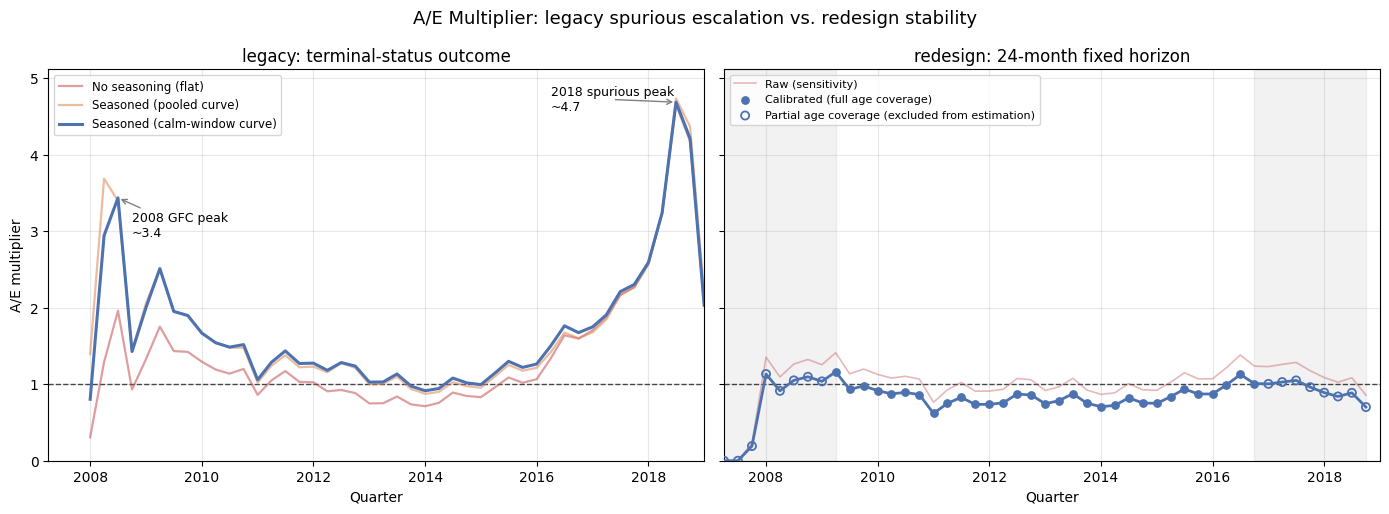

Saved -> figureL.1_multiplier_contrast.png


In [43]:
# Figure L.1 — Legacy -> Redesign A/E multiplier contrast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load both series (relative paths from the legacy/ folder) ---
v3 = pd.read_csv("multiplier_legacy.csv")                                  # legacy, same folder
v4 = pd.read_csv("../artifacts_component2/table2.2_multiplier_path.csv")   # final, sibling folder

# Quarter -> timestamp for clean time axes
v3["qd"] = pd.PeriodIndex(v3["quarter"], freq="Q").to_timestamp()
v4["qd"] = pd.PeriodIndex(v4["quarter"].astype(str), freq="Q").to_timestamp()

# Drop legacy's degenerate early quarters where the multiplier is 0
v3 = v3[v3["m_base"] > 0].copy()
v4 = v4.sort_values("qd").copy()

# Shared y-limit
ymax = max(v3["m_flat"].max(), v3["m_pooled"].max(), v3["m_base"].max()) * 1.08

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)

# ---------------- Left panel: legacy ----------------
ax = axes[0]
ax.axhline(1.0, color="black", lw=1, ls="--", alpha=0.7)
ax.plot(v3["qd"], v3["m_flat"],   color="#C44E52", lw=1.6, alpha=0.55, label="No seasoning (flat)")
ax.plot(v3["qd"], v3["m_pooled"], color="#DD8452", lw=1.6, alpha=0.55, label="Seasoned (pooled curve)")
ax.plot(v3["qd"], v3["m_base"],   color="#4C72B0", lw=2.2,             label="Seasoned (calm-window curve)")

gfc = v3.loc[v3["qd"] == "2008-07-01"]      # 2008Q3
if len(gfc):
    ax.annotate(f"2008 GFC peak\n~{gfc['m_base'].iloc[0]:.1f}",
                xy=(gfc["qd"].iloc[0], gfc["m_base"].iloc[0]),
                xytext=(10, -28), textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="grey"))
pk = v3.loc[v3["m_base"].idxmax()]
ax.annotate(f"2018 spurious peak\n~{pk['m_base']:.1f}",
            xy=(pk["qd"], pk["m_base"]),
            xytext=(-90, -6), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="grey"))

ax.set_title("legacy: terminal-status outcome", fontsize=12)
ax.set_xlabel("Quarter")
ax.set_ylabel("A/E multiplier")
ax.set_ylim(0, ymax)
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(alpha=0.3)

# ---------------- Right panel: redesign (full span, partial-coverage flagged) ----------------
ax = axes[1]
ax.axhline(1.0, color="black", lw=1, ls="--", alpha=0.7)

if "full_age_mix" in v4.columns:
    clean = v4[v4["full_age_mix"]]
    part  = v4[~v4["full_age_mix"]]
else:
    clean, part = v4, v4.iloc[0:0]

# Shade leading / trailing partial-coverage regions
if len(clean) and len(part):
    first_clean, last_clean = clean["qd"].min(), clean["qd"].max()
    if (part["qd"] < first_clean).any():
        ax.axvspan(v4["qd"].min(), first_clean, color="grey", alpha=0.10)
    if (part["qd"] > last_clean).any():
        ax.axvspan(last_clean, v4["qd"].max(), color="grey", alpha=0.10)

# Raw sensitivity — light line across full span
if "multiplier_raw" in v4.columns:
    ax.plot(v4["qd"], v4["multiplier_raw"],
            color="#C44E52", lw=1.2, alpha=0.40, label="Raw (sensitivity)")

# Calibrated primary — line across full span; solid markers on clean, hollow on partial
ax.plot(v4["qd"], v4["multiplier_calibrated"], color="#4C72B0", lw=2.0, zorder=3)
ax.scatter(clean["qd"], clean["multiplier_calibrated"],
           color="#4C72B0", s=28, zorder=4, label="Calibrated (full age coverage)")
if len(part):
    ax.scatter(part["qd"], part["multiplier_calibrated"],
               facecolors="none", edgecolors="#4C72B0", s=34, linewidths=1.3,
               zorder=4, label="Partial age coverage (excluded from estimation)")

ax.set_title("redesign: 24-month fixed horizon", fontsize=12)
ax.set_xlabel("Quarter")
ax.set_ylim(0, ymax)
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

# --- Align both panels to the same time window (makes the contrast direct) ---
xmin = min(v3["qd"].min(), v4["qd"].min())
xmax = max(v3["qd"].max(), v4["qd"].max())
for a in axes:
    a.set_xlim(xmin, xmax)

fig.suptitle("A/E Multiplier: legacy spurious escalation vs. redesign stability", fontsize=13)
plt.tight_layout()
plt.savefig("figureL.1_multiplier_contrast.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved -> figureL.1_multiplier_contrast.png")